   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🛠️ Đang tự động cấu hình lại đường dẫn Dataset...
🔄 Đang nạp mô hình YOLO tốt nhất của bạn...

📊 --- PHẦN 1: ĐÁNH GIÁ ĐỘ CHÍNH XÁC TRÊN TẬP KIỂM THỬ ---
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.5 ms, read: 11.6±3.3 MB/s, size: 58.2 KB)
val: Scanning /kaggle/input/datasets/dophucvuha/mergedatasetcomputervision/ppe_merge_train_work/merged_ppe_dataset/test/labels... 2240 images, 38 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2240/2240 220.0it/s 10.2

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


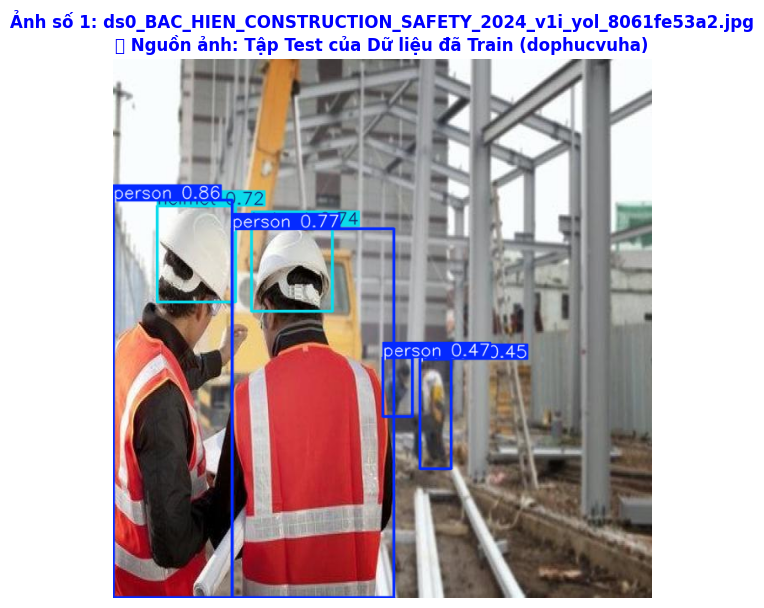

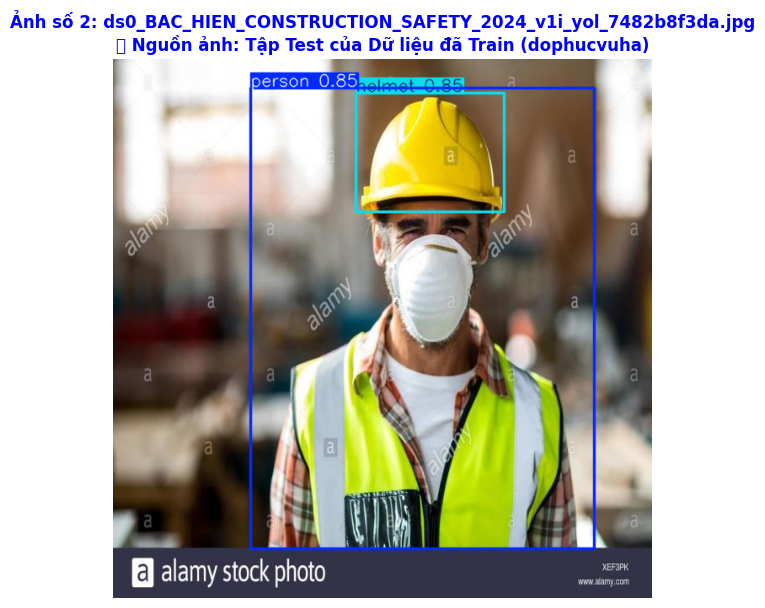

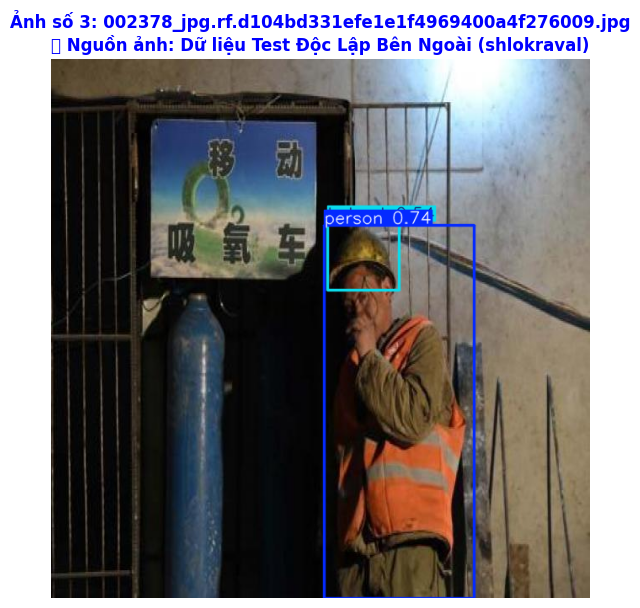

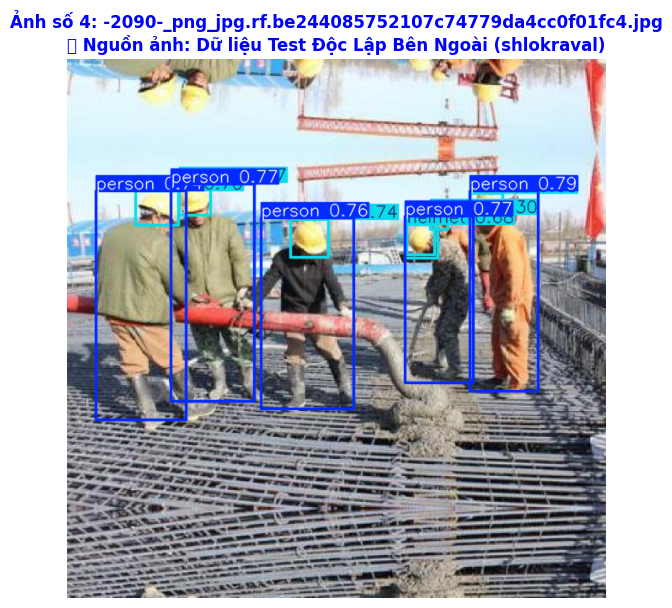

In [1]:
# Tự động cài đặt thư viện nếu máy ảo chưa có
!pip -q install ultralytics

import random
import yaml
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from ultralytics import YOLO

# =========================================================
# 1. CẤU HÌNH ĐƯỜNG DẪN GỐC CỦA BẠN
# =========================================================
MODEL_PATH = "/kaggle/input/datasets/dophucvuha/mergedatasetcomputervision/Final_ComputerVision/final_models/ppe_merged_best.pt"
ORIGINAL_YAML_PATH = "/kaggle/input/datasets/dophucvuha/mergedatasetcomputervision/ppe_merge_train_work/merged_ppe_dataset/data.yaml"

# Đường dẫn thực tế đến các thư mục chứa ảnh trên Kaggle hiện tại
DATASET_ROOT = "/kaggle/input/datasets/dophucvuha/mergedatasetcomputervision/ppe_merge_train_work/merged_ppe_dataset"
TEST_DIR_MY_TRAIN = Path(f"{DATASET_ROOT}/test/images")
TEST_DIR_EXTERNAL = Path("/kaggle/input/datasets/shlokraval/ppe-dataset-yolov8/test/images")

# =========================================================
# 2. TỰ ĐỘNG CỨU HỘ VÀ SỬA LỖI ĐƯỜNG DẪN TRONG FILE YAML
# =========================================================
print("🛠️ Đang tự động cấu hình lại đường dẫn Dataset...")
with open(ORIGINAL_YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

# Sửa lại các đường dẫn trỏ chuẩn vào vị trí /kaggle/input hiện tại
data_config['path'] = DATASET_ROOT
data_config['train'] = "train/images"
data_config['val'] = "val/images"
data_config['test'] = "test/images"

# Ghi cấu hình chuẩn này ra một file yaml tạm ở thư mục working để YOLO đọc được
FIXED_YAML_PATH = "/kaggle/working/fixed_data.yaml"
with open(FIXED_YAML_PATH, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("🔄 Đang nạp mô hình YOLO tốt nhất của bạn...")
model = YOLO(MODEL_PATH)

# =========================================================
# PHẦN 1: IN CHỈ SỐ HỌC THUẬT (ĐÁNH GIÁ TRÊN TẬP TEST CỦA BẠN)
# =========================================================
print("\n📊 --- PHẦN 1: ĐÁNH GIÁ ĐỘ CHÍNH XÁC TRÊN TẬP KIỂM THỬ ---")
# Sử dụng file FIXED_YAML_PATH vừa được sửa lỗi đường dẫn
metrics = model.val(data=FIXED_YAML_PATH, split="test", plots=True, verbose=False)

print("\n" + "="*50)
print(f"🎯 Precision (Độ chính xác dự đoán):  {metrics.results_dict['metrics/precision(B)'] * 100:.2f}%")
print(f"🎯 Recall (Độ bao phủ thực tế):       {metrics.results_dict['metrics/recall(B)'] * 100:.2f}%")
print(f"🎯 mAP50 (Chỉ số tổng thể mAP@0.5):  {metrics.results_dict['metrics/mAP50(B)'] * 100:.2f}%")
print("="*50 + "\n")

# =========================================================
# PHẦN 2: DỰ ĐOÁN ẢNH TRỰC QUAN ĐỂ THUYẾT TRÌNH
# =========================================================
print("🖼️ --- PHẦN 2: CHẠY NHẬN DIỆN TRỰC QUAN TRÊN CẢ 2 DATASET ---")

def get_all_images(folder_path):
    extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG")
    images = []
    for ext in extensions:
        images.extend(list(folder_path.glob(ext)))
    return images

imgs_my_train = get_all_images(TEST_DIR_MY_TRAIN)
imgs_external = get_all_images(TEST_DIR_EXTERNAL)

demo_list = []
if imgs_my_train:
    demo_list.append((random.choice(imgs_my_train), "Tập Test của Dữ liệu đã Train (dophucvuha)"))
    demo_list.append((random.choice(imgs_my_train), "Tập Test của Dữ liệu đã Train (dophucvuha)"))
if imgs_external:
    demo_list.append((random.choice(imgs_external), "Dữ liệu Test Độc Lập Bên Ngoài (shlokraval)"))
    demo_list.append((random.choice(imgs_external), "Dữ liệu Test Độc Lập Bên Ngoài (shlokraval)"))

for idx, (img_path, source_name) in enumerate(demo_list):
    results = model.predict(source=str(img_path), conf=0.25, save=False, verbose=False)
    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 7))
    plt.imshow(annotated_img_rgb)
    plt.title(f"Ảnh số {idx+1}: {img_path.name}\n📂 Nguồn ảnh: {source_name}", fontsize=12, color="blue", fontweight="bold")
    plt.axis("off")
    plt.show()